# Intro

If you want to follow along you please try to create a mongodb container that has some sample collections. For this use the `MongoDB using Docker` notebook in this folder.

# Text-to-Query Agents with MongoDB and langgrapth

In [1]:
from pymongo import MongoClient

In [2]:
mongodb_client = MongoClient("mongodb://localhost:27017")

In [3]:
# Check the connection to your cluster
ping_result = mongodb_client.admin.command("ping")
print(ping_result)

{'ok': 1.0}


## Basic Querying with MongoDB

In [12]:
# list of available databases in mongodb
mongodb_client.list_database_names()

['admin',
 'config',
 'local',
 'sample_airbnb',
 'sample_analytics',
 'sample_geospatial',
 'sample_guides',
 'sample_mflix',
 'sample_restaurants',
 'sample_supplies',
 'sample_training',
 'sample_weatherdata',
 'testdb']

In [14]:
# set a database
db = mongodb_client["sample_mflix"]

In [15]:
# kind of listing the tables in the database
db.list_collection_names()

['users', 'movies', 'comments', 'theaters', 'embedded_movies', 'sessions']

In [24]:
collection = db.get_collection("movies")

In [26]:
collection.find_one({})

{'_id': ObjectId('573a1390f29313caabcd42e8'),
 'plot': 'A group of bandits stage a brazen train hold-up, only to find a determined posse hot on their heels.',
 'genres': ['Short', 'Western'],
 'runtime': 11,
 'cast': ['A.C. Abadie',
  "Gilbert M. 'Broncho Billy' Anderson",
  'George Barnes',
  'Justus D. Barnes'],
 'poster': 'https://m.media-amazon.com/images/M/MV5BMTU3NjE5NzYtYTYyNS00MDVmLWIwYjgtMmYwYWIxZDYyNzU2XkEyXkFqcGdeQXVyNzQzNzQxNzI@._V1_SY1000_SX677_AL_.jpg',
 'title': 'The Great Train Robbery',
 'fullplot': "Among the earliest existing films in American cinema - notable as the first film that presented a narrative story to tell - it depicts a group of cowboy outlaws who hold up a train and rob the passengers. They are then pursued by a Sheriff's posse. Several scenes have color included - all hand tinted.",
 'languages': ['English'],
 'released': datetime.datetime(1903, 12, 1, 0, 0),
 'directors': ['Edwin S. Porter'],
 'rated': 'TV-G',
 'awards': {'wins': 1, 'nominations': 0, 

In [33]:
query = {"year": {"$lt": 1905} }

In [34]:
import pprint

for doc in collection.find(query):
    pprint.pprint(doc)

{'_id': ObjectId('573a1390f29313caabcd42e8'),
 'awards': {'nominations': 0, 'text': '1 win.', 'wins': 1},
 'cast': ['A.C. Abadie',
          "Gilbert M. 'Broncho Billy' Anderson",
          'George Barnes',
          'Justus D. Barnes'],
 'countries': ['USA'],
 'directors': ['Edwin S. Porter'],
 'fullplot': 'Among the earliest existing films in American cinema - notable '
             'as the first film that presented a narrative story to tell - it '
             'depicts a group of cowboy outlaws who hold up a train and rob '
             "the passengers. They are then pursued by a Sheriff's posse. "
             'Several scenes have color included - all hand tinted.',
 'genres': ['Short', 'Western'],
 'imdb': {'id': 439, 'rating': 7.4, 'votes': 9847},
 'languages': ['English'],
 'lastupdated': '2015-08-13 00:27:59.177000000',
 'num_mflix_comments': 0,
 'plot': 'A group of bandits stage a brazen train hold-up, only to find a '
         'determined posse hot on their heels.',
 'poster'

In [36]:
query = { "$and":[
    {"year": {"$lt": 1930}},
    {"imdb.rating" : {"$gte":8}}
        ]
    }

In [38]:
for doc in collection.find(query):
    pprint.pprint(doc)

{'_id': ObjectId('573a1391f29313caabcd6e2a'),
 'awards': {'nominations': 0, 'text': '1 win.', 'wins': 1},
 'cast': ['Buster Keaton', 'Sybil Seely'],
 'countries': ['USA'],
 'directors': ['Edward F. Cline', 'Buster Keaton'],
 'fullplot': 'Buster and Sybil exit a chapel as newlyweds. Among the gifts is '
             "a portable house you easily put together in one week. It doesn't "
             "help that Buster's rival for Sybil switches the numbers on the "
             'crates containing the house parts.',
 'genres': ['Short', 'Comedy'],
 'imdb': {'id': 11541, 'rating': 8.3, 'votes': 3942},
 'languages': ['English'],
 'lastupdated': '2015-05-07 01:07:01.633000000',
 'num_mflix_comments': 0,
 'plot': 'A newly wedded couple attempt to build a house with a prefabricated '
         "kit, unaware that a rival sabotaged the kit's component numbering.",
 'rated': 'TV-G',
 'released': datetime.datetime(1920, 9, 1, 0, 0),
 'runtime': 25,
 'title': 'One Week',
 'tomatoes': {'lastUpdated': dat

## More advanced querying with MongoDB

In [60]:
pipeline = [
    {"$match": {"imdb.rating": {"$gte": 8}}},  # Filter first
    {"$sort": {"imdb.rating": -1}},            # Sort descending
    {"$limit": 5},                             # Take top 5
    {"$project": {"title": 1, "imdb": 1, "_id": 0}}  # Only title + imdb
]

In [61]:
for doc in collection.aggregate(pipeline):
    pprint.pprint(doc)

{'imdb': {'id': 185906, 'rating': 9.6, 'votes': 183802},
 'title': 'Band of Brothers'}
{'imdb': {'id': 795176, 'rating': 9.5, 'votes': 82896}, 'title': 'Planet Earth'}
{'imdb': {'id': 3735302, 'rating': 9.4, 'votes': 45},
 'title': 'A Brave Heart: The Lizzie Velasquez Story'}
{'imdb': {'id': 98769, 'rating': 9.4, 'votes': 4624}, 'title': 'The Civil War'}
{'imdb': {'id': 98769, 'rating': 9.4, 'votes': 4625}, 'title': 'The Civil War'}


In [63]:
group_query = [ { "$unwind": "$directors" },
          { "$group": { "_id": "$directors", "filmCount": { "$sum": 1 }, "avgRating": { "$avg": "$imdb.rating" } } },
          { "$match": { "filmCount": { "$gte": 20 } } },
          { "$sort": { "avgRating": -1 } },
          { "$limit": 5 } ]

# Execute the aggregation pipeline and iterate through the resulting cursor
for doc in collection.aggregate(group_query):
    print(doc)

{'_id': 'William Wyler', 'filmCount': 21, 'avgRating': 7.676190476190476}
{'_id': 'Martin Scorsese', 'filmCount': 32, 'avgRating': 7.640625}
{'_id': 'Alfred Hitchcock', 'filmCount': 24, 'avgRating': 7.5874999999999995}
{'_id': 'Steven Spielberg', 'filmCount': 29, 'avgRating': 7.479310344827587}
{'_id': 'Woody Allen', 'filmCount': 40, 'avgRating': 7.215000000000001}


# A text-to-query workflow in practice

The end-to-end text-to-query workflow using MongoDB involves the following steps:

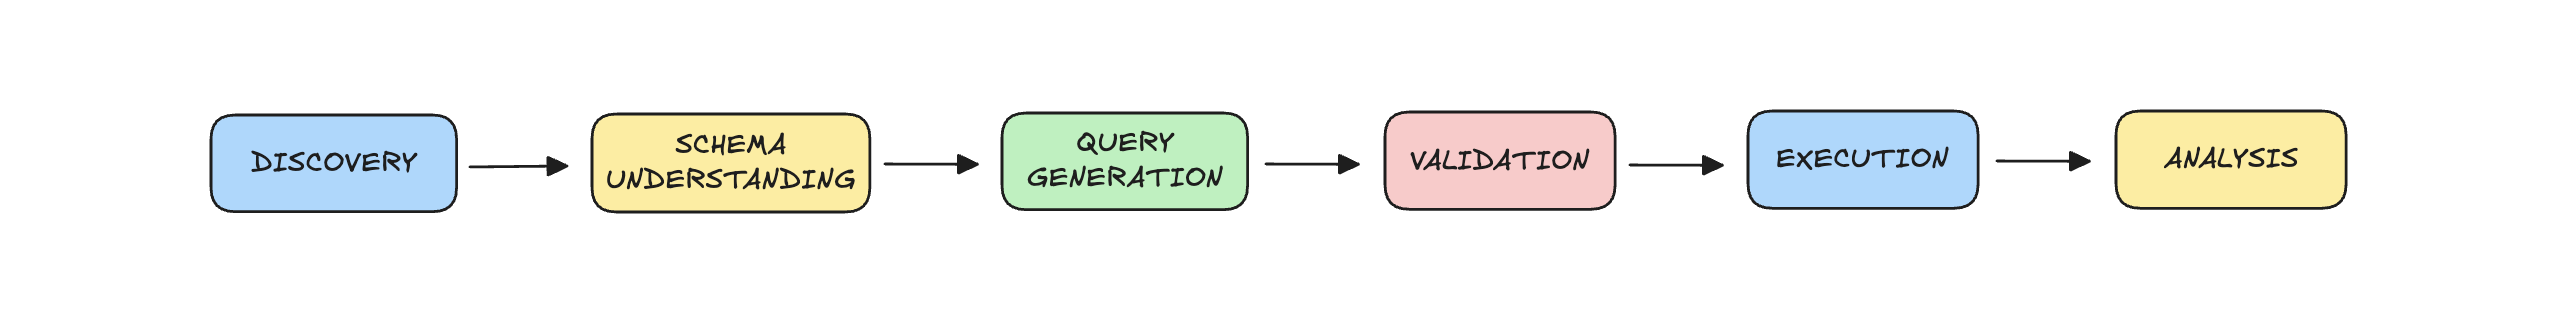

1. Identify the collection to query
2. Examine the schema of the collection to query
3. Generate the MongoDB query
4. Validate the MongoDB query
5. Execute the MongoDB query
6. Reason over the results obtained

In this exercise, we will manually do step 1 through 6. For Step 6, we will pass the results from executing the query to an LLM to reason over them and generate a natural language response to the question.

For simplicity, let's use one of the sample queries from the previous exercise. We already know that the data for this query is present in the `movies` collection, we have already previewed the schema of a sample document, and also created the query. So let's continue the text-to-query workflow from Step 4.

In [76]:
import sys
import os

# Use current working directory and go one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now you can import your config
from config import api_key

In [73]:
from pymongo import MongoClient

# create a client
mongodb_client = MongoClient("mongodb://localhost:27017")

# set a database
db = mongodb_client["sample_mflix"]

# select the movies collection/table
collection = db["movies"]

In [79]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4o-mini", temperature=0, api_key=api_key)

In [81]:
# Natural language user query
user_query = "Give me the top 5 directors by average IMDB rating, who have made at least 20 movies"

# Convert natural language query to MongoDB query
mongodb_query = [ { "$unwind": "$directors" },
          { "$group": { "_id": "$directors", "filmCount": { "$sum": 1 }, "avgRating": { "$avg": "$imdb.rating" } } },
          { "$match": { "filmCount": { "$gte": 20 } } },
          { "$sort": { "avgRating": -1 } },
          { "$limit": 5 } ]

# Execute the query and obtain results
docs = [doc for doc in collection.aggregate(mongodb_query)]
docs

[{'_id': 'William Wyler', 'filmCount': 21, 'avgRating': 7.676190476190476},
 {'_id': 'Martin Scorsese', 'filmCount': 32, 'avgRating': 7.640625},
 {'_id': 'Alfred Hitchcock', 'filmCount': 24, 'avgRating': 7.5874999999999995},
 {'_id': 'Steven Spielberg', 'filmCount': 29, 'avgRating': 7.479310344827587},
 {'_id': 'Woody Allen', 'filmCount': 40, 'avgRating': 7.215000000000001}]

For Step 6, we will first create a prompt for the LLM using the `ChatPromptTemplate` class in LangChain. This allows you to create flexible templated prompts.

Our chat prompt template will consist of a system prompt with a placeholder for the query results (`context`), and a placeholder for user and AI messages(`MessagesPlaceholder`).

We will use the `.from_messages()` method of the `ChatPromptTemplate` class since we are using different message formats, such as a 2-tuple of (message type, template) and `MessagesPlaceholder`, to create the prompt.

Create a templated prompt for the LLM, consisting of a system prompt and a placeholder for messages, using the .from_messages() method.

In [84]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Create a system prompt for the LLM
system_prompt = """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Context: {context}"""

# Create a templated prompt for the LLM
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [85]:
MessagesPlaceholder(variable_name="messages")

MessagesPlaceholder(variable_name='messages')

to pass the prompt to the LLM, we will use the | operator, which in LangChain, allows you to "chain" prompts, LLMs, parsers etc. sequentially, with the output of one serving as the input to the next.

In [86]:
# Chain the prompt with the LLM
llm_with_prompt = prompt | llm

You can call LLMs, tools etc. in LangChain using the `.invoke()` method. The inputs of the `.invoke()` method are the inputs to the LLM/tool. You can also pass placeholder values as inputs to the `.invoke()` **method.**

**Invoke the `llm_with_prompt` chain with the query results and the user query as inputs.**

In [92]:
import json

response = llm_with_prompt.invoke({"context": json.dumps(docs), "messages":[("user",user_query)]})

print(response.content)

The top 5 directors by average IMDB rating, who have made at least 20 movies, are:

1. William Wyler - Avg Rating: 7.68 (21 films)
2. Martin Scorsese - Avg Rating: 7.64 (32 films)
3. Alfred Hitchcock - Avg Rating: 7.59 (24 films)
4. Steven Spielberg - Avg Rating: 7.48 (29 films)
5. Woody Allen - Avg Rating: 7.22 (40 films)
